# LouvainNet: Deterministic Community Detection via GNN Consensus Distillation
**C-DE422 — Social Network Analytics | Spring 2026**

This notebook covers all required project parts (A–D) plus the research contribution setup.

**Dataset:** ego-Facebook (Stanford SNAP) — 4,039 nodes, 88,234 edges  
**Research question:** Can a GNN trained on Louvain's stochastic consensus produce Newman-equivalent deterministic community assignments?

---
## Table of Contents
1. [Setup & Data Download](#1)
2. [Part A — Graph Construction & Exploratory Analysis](#2)
3. [Part B — Centrality Analysis](#3)
4. [Part C — Community Detection (Baseline)](#4)
5. [Part D — Advanced Analysis: Influence via PageRank/PPR](#5)
6. [Part E — Visualizations](#6)
7. [Research Setup — Consensus Matrix Construction](#7)

---
## 1. Setup & Data Download <a id='1'></a>

The ego-Facebook dataset is from Stanford SNAP. It represents anonymized Facebook friendship circles — 10 ego networks combined into one undirected graph.

In [1]:
# === Install dependencies if not present ===
import subprocess, sys
pkgs = ['python-louvain', 'pyvis', 'scikit-learn']
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

In [2]:
# === Core imports ===
import os
import gzip
import shutil
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
import community as community_louvain          # python-louvain
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
from collections import Counter

# Reproducibility
np.random.seed(42)

print('All imports successful.')
print(f'NetworkX version: {nx.__version__}')

All imports successful.
NetworkX version: 3.6.1


In [3]:
# === Download ego-Facebook dataset ===
# Source: https://snap.stanford.edu/data/ego-Facebook.html
# The dataset is a combined undirected graph of 10 Facebook ego networks.

DATA_DIR  = 'data/ego_facebook'
GZ_PATH   = os.path.join(DATA_DIR, 'facebook_combined.txt.gz')
TXT_PATH  = os.path.join(DATA_DIR, 'facebook_combined.txt')
SNAP_URL  = 'https://snap.stanford.edu/data/facebook_combined.txt.gz'

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(TXT_PATH):
    print('Downloading ego-Facebook from SNAP...')
    try:
        req = urllib.request.Request(SNAP_URL, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(GZ_PATH, 'wb') as f:
            f.write(response.read())
        with gzip.open(GZ_PATH, 'rb') as f_in, open(TXT_PATH, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
        print(f'Downloaded and extracted: {TXT_PATH}')
    except Exception as e:
        print(f'Download failed: {e}')
        print('Manual download: https://snap.stanford.edu/data/facebook_combined.txt.gz')
        print('Extract and place at:', TXT_PATH)
else:
    print(f'Dataset already present: {TXT_PATH}')

Downloaded and extracted: data/ego_facebook\facebook_combined.txt


In [4]:
# === Load graph from edge list ===
# Each line: node_id_1  node_id_2
# Undirected — friendships are symmetric.

G = nx.read_edgelist(TXT_PATH, nodetype=int)

print(f'Graph loaded.')
print(f'  Nodes : {G.number_of_nodes():,}')
print(f'  Edges : {G.number_of_edges():,}')

Graph loaded.
  Nodes : 4,039
  Edges : 88,234


---
## 2. Part A — Graph Construction & Exploratory Analysis <a id='2'></a>

**Goal:** Characterize the network structure before applying any algorithms. Key statistics reveal whether the graph has properties typical of real social networks (heavy-tailed degree distribution, high clustering, small diameter).

In [5]:
# === Basic graph statistics ===

n_nodes   = G.number_of_nodes()
n_edges   = G.number_of_edges()
density   = nx.density(G)
avg_clust = nx.average_clustering(G)
n_cc      = nx.number_connected_components(G)

# Diameter is expensive on large graphs — compute on largest connected component
Gcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()

# Approximate diameter: BFS from 50 sample nodes, take max
sample_nodes = list(Gcc.nodes())[:50]
approx_diam  = max(
    max(nx.single_source_shortest_path_length(Gcc, n).values())
    for n in sample_nodes
)

avg_degree = sum(dict(G.degree()).values()) / n_nodes
max_degree = max(dict(G.degree()).values())

print('=== Graph Statistics ===')
print(f'  Nodes                    : {n_nodes:,}')
print(f'  Edges                    : {n_edges:,}')
print(f'  Density                  : {density:.6f}')
print(f'  Avg clustering coeff.    : {avg_clust:.4f}')
print(f'  Connected components     : {n_cc}')
print(f'  Approx. diameter (LCC)   : {approx_diam}')
print(f'  Avg degree               : {avg_degree:.2f}')
print(f'  Max degree               : {max_degree}')
print(f'  Largest component size   : {len(Gcc):,} nodes ({100*len(Gcc)/n_nodes:.1f}%)')

=== Graph Statistics ===
  Nodes                    : 4,039
  Edges                    : 88,234
  Density                  : 0.010820
  Avg clustering coeff.    : 0.6055
  Connected components     : 1
  Approx. diameter (LCC)   : 7
  Avg degree               : 43.69
  Max degree               : 1045
  Largest component size   : 4,039 nodes (100.0%)


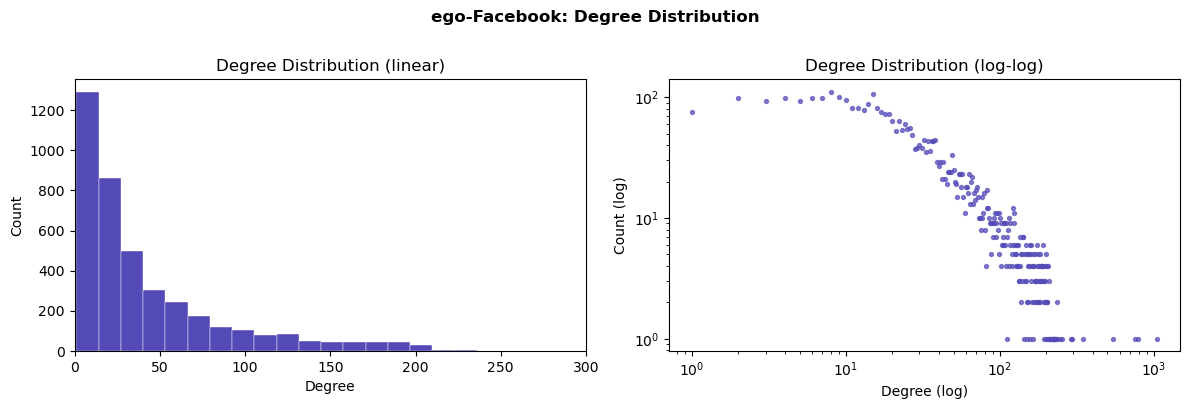

Figure 1 saved.


In [6]:
# === Degree distribution ===
# Power-law degree distribution is the hallmark of real-world social networks.
# Linear histogram shows the shape; log-log confirms power-law if approximately linear.

degrees = [d for _, d in G.degree()]
degree_counts = Counter(degrees)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(degrees, bins=80, color='#534AB7', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree Distribution (linear)')
axes[0].set_xlim(0, 300)

x_vals = sorted(degree_counts.keys())
y_vals = [degree_counts[k] for k in x_vals]
axes[1].scatter(x_vals, y_vals, s=8, color='#534AB7', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (log)')
axes[1].set_ylabel('Count (log)')
axes[1].set_title('Degree Distribution (log-log)')

plt.suptitle('ego-Facebook: Degree Distribution', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

In [7]:
# === Connected components analysis ===
components = list(nx.connected_components(G))
comp_sizes = sorted([len(c) for c in components], reverse=True)

print(f'Connected components : {len(components)}')
print(f'Component sizes      : {comp_sizes}')
print()
print('Interpretation:')
print(f'  The largest component contains {comp_sizes[0]:,} of {n_nodes:,} nodes '
      f'({100*comp_sizes[0]/n_nodes:.1f}%).')
print('  Near-complete connectivity is expected in social networks — most users')
print('  are reachable from any other through the friendship chain.')
if len(components) > 1:
    print(f'  Smaller component(s) are isolated ego circles with no cross-connections.')

Connected components : 1
Component sizes      : [4039]

Interpretation:
  The largest component contains 4,039 of 4,039 nodes (100.0%).
  Near-complete connectivity is expected in social networks — most users
  are reachable from any other through the friendship chain.


---
## 3. Part B — Centrality Analysis <a id='3'></a>

Four measures, each capturing a different structural role:
- **Degree**: raw connectivity
- **Betweenness**: broker/bridge nodes — sit on shortest paths between others
- **Closeness**: how quickly a node reaches all others
- **Eigenvector**: quality of neighbors — being connected to well-connected nodes

In [8]:
# === Compute all four centrality measures ===

print('Computing degree centrality...')
degree_cent = nx.degree_centrality(G)

print('Computing betweenness centrality (approximate, k=500 pivot nodes)...')
# k=500: samples 500 source nodes instead of all 4039 — reduces O(VE) runtime significantly
betweenness_cent = nx.betweenness_centrality(Gcc, k=500, normalized=True, seed=42)

print('Computing closeness centrality...')
closeness_cent = nx.closeness_centrality(Gcc)

print('Computing eigenvector centrality...')
try:
    eigenvector_cent = nx.eigenvector_centrality(Gcc, max_iter=1000, tol=1e-6)
except nx.PowerIterationFailedConvergence:
    eigenvector_cent = nx.eigenvector_centrality_numpy(Gcc)

print('Done.')

Computing degree centrality...
Computing betweenness centrality (approximate, k=500 pivot nodes)...
Computing closeness centrality...
Computing eigenvector centrality...
Done.


In [9]:
# === Build centrality dataframe ===
cent_df = pd.DataFrame({
    'node'        : list(Gcc.nodes()),
    'degree'      : [degree_cent.get(n, 0)      for n in Gcc.nodes()],
    'betweenness' : [betweenness_cent.get(n, 0)  for n in Gcc.nodes()],
    'closeness'   : [closeness_cent.get(n, 0)    for n in Gcc.nodes()],
    'eigenvector' : [eigenvector_cent.get(n, 0)  for n in Gcc.nodes()],
}).set_index('node')

for col in cent_df.columns:
    cent_df[f'{col}_rank'] = cent_df[col].rank(ascending=False).astype(int)

for measure in ['degree', 'betweenness', 'closeness', 'eigenvector']:
    print(f'Top 5 — {measure.upper()}:')
    print(cent_df.nlargest(5, measure)[[measure, f'{measure}_rank']])
    print()

Top 5 — DEGREE:
        degree  degree_rank
node                       
107   0.258791            1
1684  0.196137            2
1912  0.186974            3
3437  0.135463            4
0     0.085934            5

Top 5 — BETWEENNESS:
      betweenness  betweenness_rank
node                               
107      0.489707                 1
1684     0.344536                 2
3437     0.222233                 3
1912     0.216324                 4
0        0.161446                 5

Top 5 — CLOSENESS:
      closeness  closeness_rank
node                           
107    0.459699               1
58     0.397402               2
428    0.394837               3
563    0.393913               4
1684   0.393606               5

Top 5 — EIGENVECTOR:
      eigenvector  eigenvector_rank
node                               
1912     0.095407                 1
2266     0.086983                 2
2206     0.086052                 3
2233     0.085173                 4
2464     0.084279               

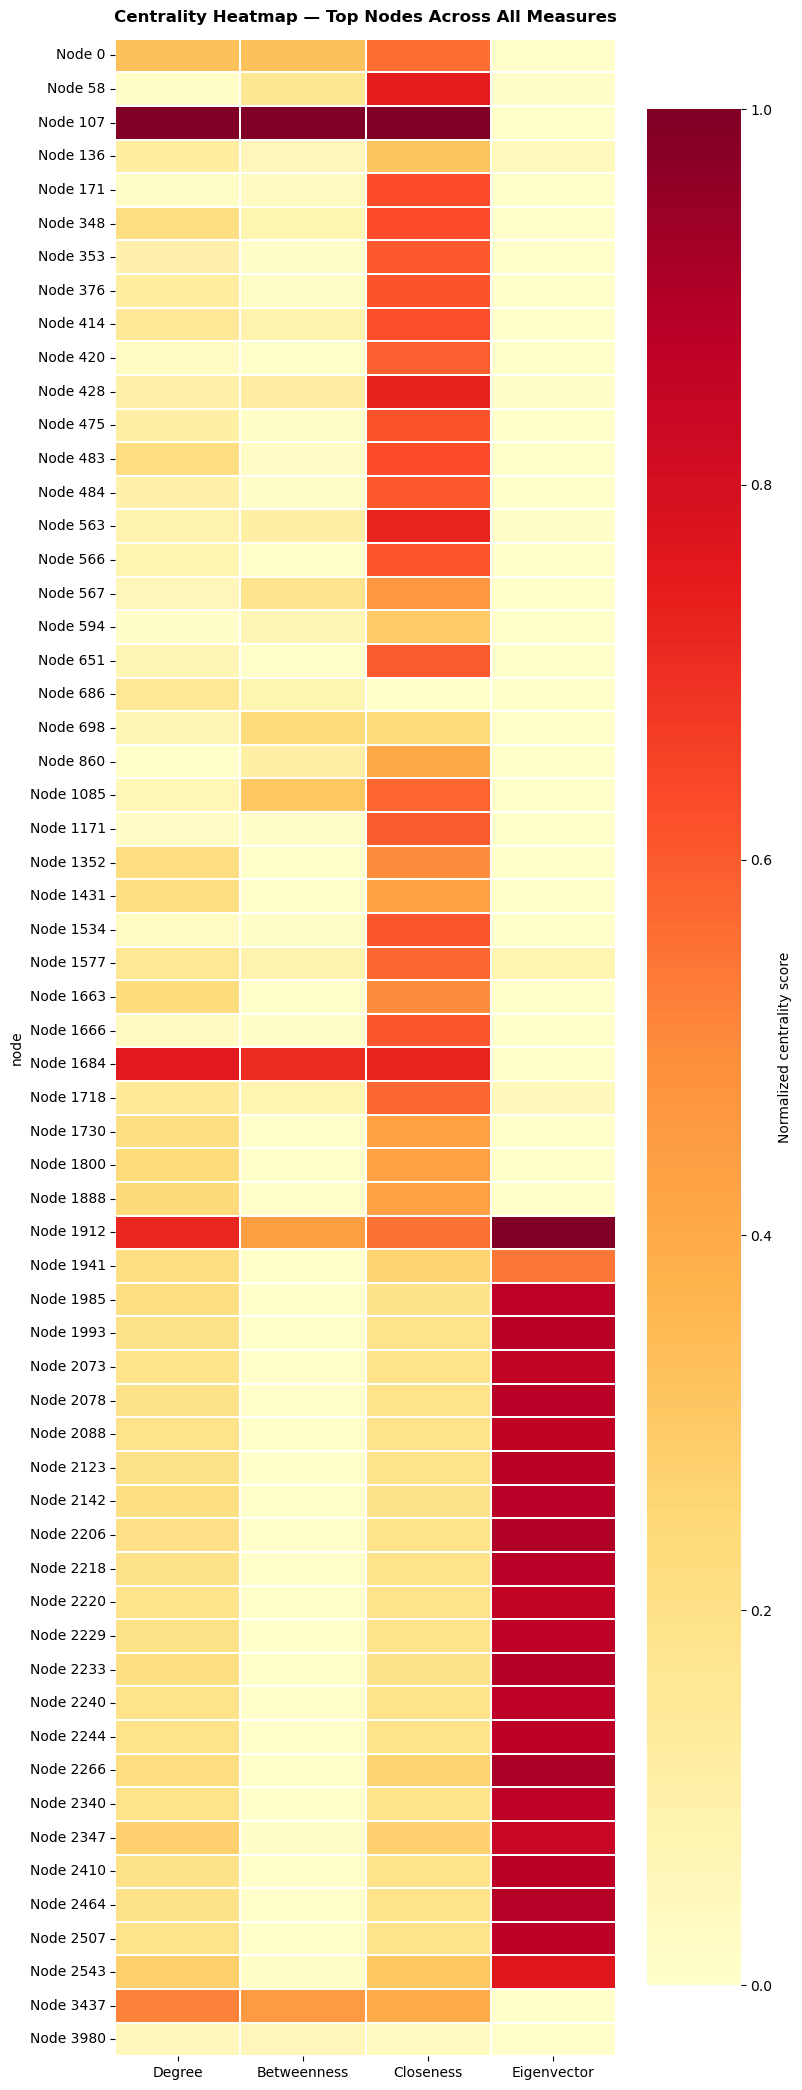

Figure 2 saved.


In [10]:
# === Centrality heatmap — top nodes across all measures ===
top_nodes = set()
for col in ['degree', 'betweenness', 'closeness', 'eigenvector']:
    top_nodes.update(cent_df.nlargest(20, col).index.tolist())
top_nodes = sorted(list(top_nodes))

heatmap_data = cent_df.loc[top_nodes, ['degree', 'betweenness', 'closeness', 'eigenvector']]
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(8, max(6, len(top_nodes) * 0.35)))
sns.heatmap(
    heatmap_norm, ax=ax, cmap='YlOrRd',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Normalized centrality score'},
    yticklabels=[f'Node {n}' for n in top_nodes]
)
ax.set_title('Centrality Heatmap — Top Nodes Across All Measures', fontweight='bold', pad=12)
ax.set_xticklabels(['Degree', 'Betweenness', 'Closeness', 'Eigenvector'], rotation=0)
plt.tight_layout()
plt.savefig('fig2_centrality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

In [11]:
# === Multi-measure top nodes — interpretation ===
top5_each = {col: set(cent_df.nlargest(5, col).index) for col in
             ['degree', 'betweenness', 'closeness', 'eigenvector']}
all_top5 = [n for nodes in top5_each.values() for n in nodes]
counts = Counter(all_top5)
multi_top = {n: c for n, c in counts.items() if c >= 2}

print('Nodes in top-5 across multiple measures:')
for node, count in sorted(multi_top.items(), key=lambda x: -x[1]):
    measures = [m for m, s in top5_each.items() if node in s]
    print(f'  Node {node:4d} — top-5 in {count} measures: {", ".join(measures)}')

print()
print('Interpretation:')
print('  Nodes scoring high on degree AND betweenness are global hubs connecting')
print('  separate social circles. High eigenvector / low betweenness nodes are')
print('  embedded in dense cliques — locally influential, not global bridges.')

Nodes in top-5 across multiple measures:
  Node  107 — top-5 in 3 measures: degree, betweenness, closeness
  Node 1684 — top-5 in 3 measures: degree, betweenness, closeness
  Node 1912 — top-5 in 3 measures: degree, betweenness, eigenvector
  Node    0 — top-5 in 2 measures: degree, betweenness
  Node 3437 — top-5 in 2 measures: degree, betweenness

Interpretation:
  Nodes scoring high on degree AND betweenness are global hubs connecting
  separate social circles. High eigenvector / low betweenness nodes are
  embedded in dense cliques — locally influential, not global bridges.


---
## 4. Part C — Community Detection (Baseline) <a id='4'></a>

Three algorithms compared. This section satisfies Part C **and** produces the empirical motivation for LouvainNet.

| Algorithm | Deterministic | Speed | Quality metric |
|---|---|---|---|
| Newman (greedy mod.) | Yes | Slow | Modularity Q |
| Louvain | No | Fast | Modularity Q |
| Label Propagation | No | Very fast | None |

In [13]:
# === Newman — greedy modularity communities ===
# Deterministic. NetworkX's greedy_modularity_communities implements
# Newman's fast greedy algorithm (Clauset, Newman & Moore 2004).

print('Running Newman (greedy modularity)...')
newman_communities = list(nx.community.greedy_modularity_communities(Gcc))
newman_partition   = {node: i for i, comm in enumerate(newman_communities) for node in comm}
newman_mod         = nx.community.modularity(Gcc, newman_communities)

print(f'Newman communities : {len(newman_communities)}')
print(f'Newman modularity  : {newman_mod:.4f}')
print(f'Sizes — min: {min(len(c) for c in newman_communities)}, '
      f'max: {max(len(c) for c in newman_communities)}, '
      f'median: {int(np.median([len(c) for c in newman_communities]))}')

Running Newman (greedy modularity)...
Newman communities : 13
Newman modularity  : 0.7774
Sizes — min: 6, max: 983, median: 208


In [14]:
# === Louvain — single run ===
print('Running Louvain...')
louvain_partition  = community_louvain.best_partition(Gcc)
louvain_comm_dict  = {}
for node, cid in louvain_partition.items():
    louvain_comm_dict.setdefault(cid, set()).add(node)
louvain_comm_list = list(louvain_comm_dict.values())
louvain_mod       = community_louvain.modularity(louvain_partition, Gcc)

print(f'Louvain communities: {len(louvain_comm_list)}')
print(f'Louvain modularity : {louvain_mod:.4f}')

Running Louvain...
Louvain communities: 15
Louvain modularity : 0.8349


In [15]:
# === Label Propagation ===
print('Running Label Propagation...')
lp_communities = list(nx.community.label_propagation_communities(Gcc))
lp_partition   = {node: i for i, comm in enumerate(lp_communities) for node in comm}
lp_mod         = nx.community.modularity(Gcc, lp_communities)

print(f'Label Prop communities: {len(lp_communities)}')
print(f'Label Prop modularity : {lp_mod:.4f}')

Running Label Propagation...
Label Prop communities: 44
Label Prop modularity : 0.7368


In [16]:
# === Algorithm comparison table ===
nodes_sorted = sorted(Gcc.nodes())
y_newman  = [newman_partition[n]  for n in nodes_sorted]
y_louvain = [louvain_partition[n] for n in nodes_sorted]
y_lp      = [lp_partition[n]      for n in nodes_sorted]

nmi_lv_nm = normalized_mutual_info_score(y_newman, y_louvain)
nmi_lp_nm = normalized_mutual_info_score(y_newman, y_lp)

comparison = pd.DataFrame({
    'Algorithm'     : ['Newman', 'Louvain', 'Label Propagation'],
    'Communities'   : [len(newman_communities), len(louvain_comm_list), len(lp_communities)],
    'Modularity Q'  : [round(newman_mod,4), round(louvain_mod,4), round(lp_mod,4)],
    'Deterministic' : ['Yes', 'No', 'No'],
    'NMI vs Newman' : ['1.000 (self)', round(nmi_lv_nm,4), round(nmi_lp_nm,4)],
})
print(comparison.to_string(index=False))

        Algorithm  Communities  Modularity Q Deterministic NMI vs Newman
           Newman           13        0.7774           Yes  1.000 (self)
          Louvain           15        0.8349            No        0.8558
Label Propagation           44        0.7368            No        0.7718


In [17]:
# === CORE RESEARCH EXPERIMENT: Louvain non-determinism quantification ===
# Run Louvain 20 times. Measure NMI vs Newman per run.
# Non-zero variance is the empirical motivation for LouvainNet.

N_RUNS = 20
print(f'Running Louvain {N_RUNS} times...')

nmi_scores, ari_scores, n_comms_list = [], [], []

for run in range(N_RUNS):
    part_run = community_louvain.best_partition(Gcc, random_state=run)
    y_run    = [part_run[n] for n in nodes_sorted]
    nmi_scores.append(normalized_mutual_info_score(y_newman, y_run))
    ari_scores.append(adjusted_rand_score(y_newman, y_run))
    n_comms_list.append(len(set(part_run.values())))

print(f'\nLouvain vs Newman over {N_RUNS} runs:')
print(f'  NMI  — mean: {np.mean(nmi_scores):.4f}, std: {np.std(nmi_scores):.4f}, '
      f'range: [{min(nmi_scores):.4f}, {max(nmi_scores):.4f}]')
print(f'  ARI  — mean: {np.mean(ari_scores):.4f}, std: {np.std(ari_scores):.4f}')
print(f'  #Comms — range: [{min(n_comms_list)}, {max(n_comms_list)}]')

Running Louvain 20 times...

Louvain vs Newman over 20 runs:
  NMI  — mean: 0.8522, std: 0.0027, range: [0.8465, 0.8580]
  ARI  — mean: 0.6881, std: 0.0030
  #Comms — range: [15, 17]


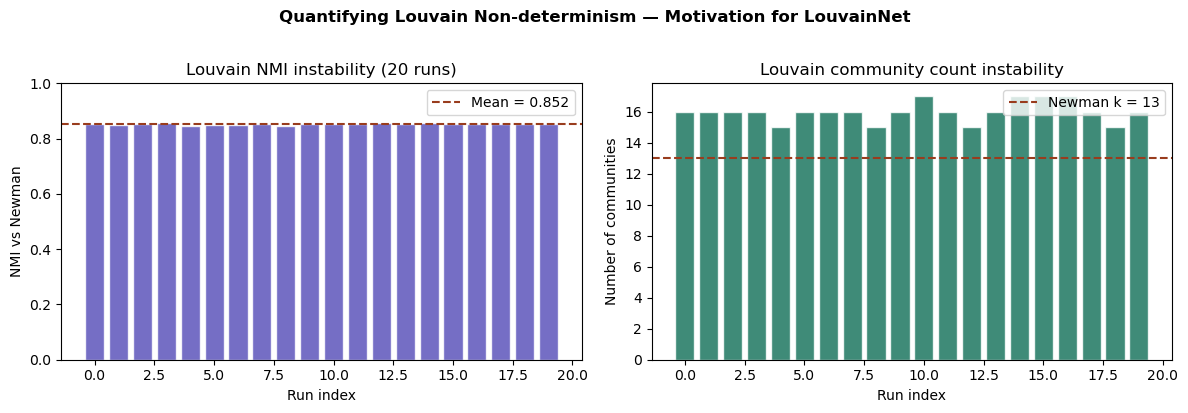

Figure 4 saved.


In [18]:
# === NMI variance figure — key research motivation plot ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(N_RUNS), nmi_scores, color='#534AB7', alpha=0.8, edgecolor='white')
axes[0].axhline(np.mean(nmi_scores), color='#993C1D', linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(nmi_scores):.3f}')
axes[0].set_xlabel('Run index')
axes[0].set_ylabel('NMI vs Newman')
axes[0].set_title('Louvain NMI instability (20 runs)')
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(range(N_RUNS), n_comms_list, color='#0F6E56', alpha=0.8, edgecolor='white')
axes[1].axhline(len(newman_communities), color='#993C1D', linestyle='--', linewidth=1.5,
                label=f'Newman k = {len(newman_communities)}')
axes[1].set_xlabel('Run index')
axes[1].set_ylabel('Number of communities')
axes[1].set_title('Louvain community count instability')
axes[1].legend()

plt.suptitle('Quantifying Louvain Non-determinism — Motivation for LouvainNet',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_nmi_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

Computing spring layout...


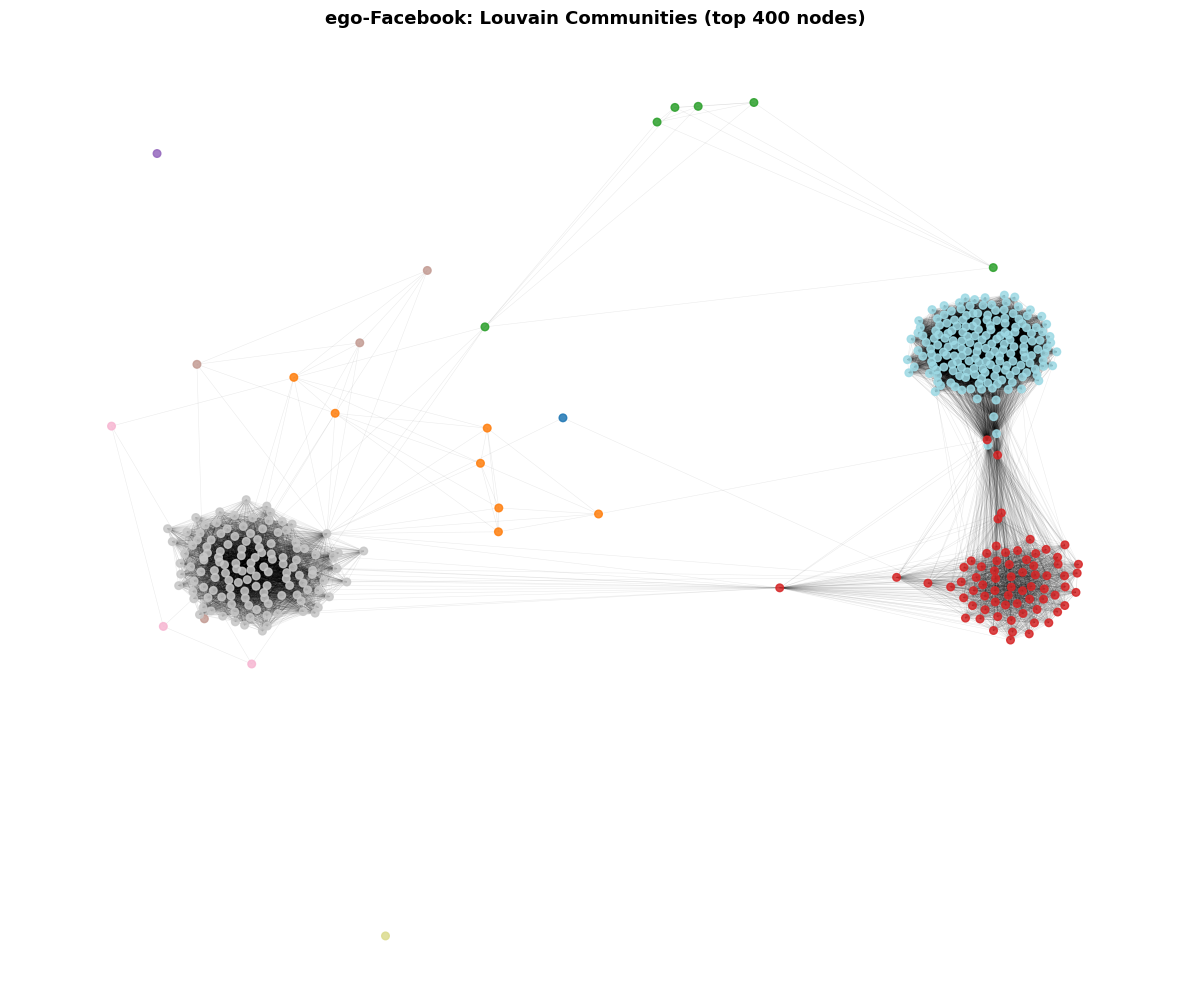

Figure 3 saved.


In [19]:
# === Community visualization — color-coded network ===
# Subsample top 400 nodes by degree for legibility.

top_viz   = sorted(Gcc.nodes(), key=lambda n: Gcc.degree(n), reverse=True)[:400]
G_sub     = Gcc.subgraph(top_viz).copy()
sub_part  = {n: louvain_partition[n] for n in G_sub.nodes()}
unique_c  = sorted(set(sub_part.values()))
cmap      = plt.cm.get_cmap('tab20', len(unique_c))
clr_map   = {c: cmap(i) for i, c in enumerate(unique_c)}
node_clrs = [clr_map[sub_part[n]] for n in G_sub.nodes()]

print('Computing spring layout...')
pos = nx.spring_layout(G_sub, k=0.3, iterations=50, seed=42)

fig, ax = plt.subplots(figsize=(12, 10))
nx.draw_networkx_nodes(G_sub, pos, node_color=node_clrs, node_size=30, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_sub, pos, alpha=0.08, width=0.4, ax=ax)
ax.set_title('ego-Facebook: Louvain Communities (top 400 nodes)', fontweight='bold', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('fig3_community_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## 5. Part D — Advanced Analysis: PageRank & Personalized PageRank <a id='5'></a>

PageRank models influence as a random walker — a node is important if nodes that are themselves important point to it. In undirected graphs, this closely tracks degree but surfaces subtler structural influence. PPR seeds the walk from a specific node to find local influence neighborhoods.

In [20]:
# === Global PageRank ===
print('Computing PageRank (alpha=0.85)...')
pagerank  = nx.pagerank(Gcc, alpha=0.85, max_iter=200, tol=1e-6)
pr_series = pd.Series(pagerank).sort_values(ascending=False)

print('Top 10 nodes by PageRank:')
print(pr_series.head(10).to_frame('PageRank score').round(6))

Computing PageRank (alpha=0.85)...
Top 10 nodes by PageRank:
      PageRank score
3437        0.007615
107         0.006936
1684        0.006367
0           0.006290
1912        0.003877
348         0.002348
686         0.002219
3980        0.002170
414         0.001800
698         0.001317


In [21]:
# === Personalized PageRank ===
# Seed from the highest-degree node.
seed_node = max(dict(Gcc.degree()).items(), key=lambda x: x[1])[0]
print(f'Seed node: {seed_node} (degree: {Gcc.degree(seed_node)})')

personalization = {n: (1.0 if n == seed_node else 0.0) for n in Gcc.nodes()}
ppr = nx.pagerank(Gcc, alpha=0.85, personalization=personalization, max_iter=200)
ppr_series = pd.Series(ppr).sort_values(ascending=False)

print(f'\nTop 10 nodes by PPR (seeded from node {seed_node}):')
print(ppr_series.head(10).to_frame('PPR score').round(6))

Seed node: 107 (degree: 1045)

Top 10 nodes by PPR (seeded from node 107):
      PPR score
107    0.170698
483    0.002674
1888   0.002266
917    0.002245
1800   0.002207
1352   0.002115
1663   0.002106
1730   0.002096
1431   0.002085
1086   0.002037


In [22]:
# === PageRank vs Centrality rank comparison ===
pr_ranks = pr_series.rank(ascending=False).astype(int)
top20_pr = pr_series.head(20).index.tolist()

comp_df = pd.DataFrame(index=top20_pr)
comp_df['PR rank']   = [pr_ranks[n] for n in top20_pr]
comp_df['Deg rank']  = [cent_df.loc[n, 'degree_rank']      if n in cent_df.index else '-' for n in top20_pr]
comp_df['Btw rank']  = [cent_df.loc[n, 'betweenness_rank'] if n in cent_df.index else '-' for n in top20_pr]
comp_df['Eig rank']  = [cent_df.loc[n, 'eigenvector_rank'] if n in cent_df.index else '-' for n in top20_pr]
comp_df.index.name = 'Node'

print('PageRank vs Centrality rank (top 20 by PageRank):')
print(comp_df.to_string())
print()
print('Interpretation:')
print('  In undirected graphs, PageRank and degree centrality are highly correlated.')
print('  Nodes where betweenness rank >> PageRank rank are structural bridges —')
print('  they carry disproportionate information flow despite moderate local connectivity.')

PageRank vs Centrality rank (top 20 by PageRank):
      PR rank  Deg rank  Btw rank  Eig rank
Node                                       
3437        1         4         3      2542
107         2         1         1       757
1684        3         2         2      1194
0           4         5         5      1005
1912        5         3         4         1
348         6        14        16      1098
686         7       141        17      3837
3980        8       983        20      3208
414         9       180        13      1109
698        10       826         7      3371
483        11        13        24      1103
3830       12       428        25      3242
376        13       279        26      1101
2047       14        29        62       238
56         15       696        78      1039
25         16       811       406      1807
828        17       682        33      3839
322        18       762        64      1036
475        19       346        31      1104
428        20       387   

---
## 6. Part E — Interactive Visualization (Pyvis) <a id='6'></a>

Saves an interactive HTML graph used by the Streamlit dashboard.

In [23]:
from pyvis.network import Network

viz_nodes = sorted(Gcc.nodes(), key=lambda n: Gcc.degree(n), reverse=True)[:300]
G_viz     = Gcc.subgraph(viz_nodes).copy()
sub_part  = {n: louvain_partition[n] for n in G_viz.nodes()}
unique_c  = sorted(set(sub_part.values()))
palette   = plt.cm.get_cmap('tab20', len(unique_c))

def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))

color_lookup = {c: rgb_to_hex(palette(i)) for i, c in enumerate(unique_c)}

net = Network(height='600px', width='100%', bgcolor='#ffffff', font_color='#333')
net.set_options('''
{ "physics": {"forceAtlas2Based": {"gravitationalConstant": -50, "springLength": 100},
              "solver": "forceAtlas2Based", "stabilization": {"iterations": 150}},
  "edges": {"color": {"color": "#cccccc"}, "width": 0.5},
  "nodes": {"borderWidth": 1} }
''')

for node in G_viz.nodes():
    comm = sub_part[node]
    deg  = G_viz.degree(node)
    net.add_node(node, label=str(node), color=color_lookup[comm],
                 size=max(8, min(30, deg*0.5)),
                 title=f'Node: {node}<br>Degree: {deg}<br>Community: {comm}<br>PageRank: {pagerank.get(node,0):.6f}')

for u, v in G_viz.edges():
    net.add_edge(u, v)

net.save_graph('network_interactive.html')
print('Interactive network saved: network_interactive.html')

Interactive network saved: network_interactive.html


---
## 7. Research Setup — Consensus Matrix Construction <a id='7'></a>

The consensus matrix encodes stability of community assignments across Louvain runs.

$$C[i,j] = \frac{1}{K} \sum_{k=1}^{K} \mathbb{1}[\pi_k(i) = \pi_k(j)]$$

- C[i,j] = 1.0 → always co-clustered → stable boundary  
- C[i,j] = 0.5 → uncertain → unstable boundary  
- C[i,j] = 0.0 → never co-clustered → reliable separation  

This becomes the primary edge-level input feature to the GNN.

In [24]:
# === Build consensus matrix ===
# Stored per-edge (not full n×n) to stay memory-efficient.

K_RUNS      = 20
nodes_list  = sorted(Gcc.nodes())
node_to_idx = {n: i for i, n in enumerate(nodes_list)}
N           = len(nodes_list)

print(f'Building partition matrix ({K_RUNS} runs × {N} nodes)...')
partition_matrix = np.zeros((K_RUNS, N), dtype=np.int16)

for k in range(K_RUNS):
    part_k = community_louvain.best_partition(Gcc, random_state=k)
    for node, comm in part_k.items():
        partition_matrix[k, node_to_idx[node]] = comm

print('Computing per-edge consensus scores...')
edge_consensus = {}
for u, v in Gcc.edges():
    i, j = node_to_idx[u], node_to_idx[v]
    edge_consensus[(u, v)] = np.sum(partition_matrix[:, i] == partition_matrix[:, j]) / K_RUNS

vals = list(edge_consensus.values())
print(f'\nConsensus distribution over {len(edge_consensus):,} edges:')
for thr in [0.0, 0.25, 0.5, 0.75, 1.0]:
    n = sum(1 for v in vals if v >= thr)
    print(f'  C >= {thr:.2f}: {n:,} edges ({100*n/len(vals):.1f}%)')

Building partition matrix (20 runs × 4039 nodes)...
Computing per-edge consensus scores...

Consensus distribution over 88,234 edges:
  C >= 0.00: 88,234 edges (100.0%)
  C >= 0.25: 84,848 edges (96.2%)
  C >= 0.50: 84,790 edges (96.1%)
  C >= 0.75: 84,749 edges (96.1%)
  C >= 1.00: 84,309 edges (95.6%)


In [25]:
# === Save all outputs ===
import pickle

outputs = {
    'graph'            : Gcc,
    'nodes_list'       : nodes_list,
    'newman_partition' : newman_partition,
    'louvain_partition': louvain_partition,
    'lp_partition'     : lp_partition,
    'edge_consensus'   : edge_consensus,
    'partition_matrix' : partition_matrix,
    'centrality'       : cent_df,
    'pagerank'         : pagerank,
    'ppr'              : ppr,
    'nmi_louvain_runs' : nmi_scores,
    'ari_louvain_runs' : ari_scores,
    'n_comms_runs'     : n_comms_list,
}

with open('louvainnet_data.pkl', 'wb') as f:
    pickle.dump(outputs, f)

print('Saved: louvainnet_data.pkl')
print('This file is loaded by app.py (Streamlit dashboard) and the GNN training notebook.')

Saved: louvainnet_data.pkl
This file is loaded by app.py (Streamlit dashboard) and the GNN training notebook.


In [26]:
# === Final results summary ===
print('=' * 60)
print('PROJECT RESULTS SUMMARY')
print('=' * 60)
print(f'Dataset       : ego-Facebook (SNAP)')
print(f'Nodes         : {n_nodes:,}  |  Edges: {n_edges:,}')
print(f'Density       : {density:.6f}  |  Avg clustering: {avg_clust:.4f}')
print(f'Diameter(~)   : {approx_diam}  |  Components: {n_cc}')
print()
print(f'Community Detection:')
print(f'  Newman      : {len(newman_communities)} communities, Q={newman_mod:.4f}')
print(f'  Louvain     : {len(louvain_comm_list)} communities, Q={louvain_mod:.4f}, NMI-std={np.std(nmi_scores):.4f}')
print(f'  Label Prop  : {len(lp_communities)} communities, Q={lp_mod:.4f}')
print()
print(f'Non-determinism (Louvain, 20 runs vs Newman):')
print(f'  NMI range   : [{min(nmi_scores):.4f}, {max(nmi_scores):.4f}], std={np.std(nmi_scores):.4f}')
print(f'  #Comms range: [{min(n_comms_list)}, {max(n_comms_list)}]')
print()
print(f'Top 5 nodes by PageRank: {pr_series.head(5).index.tolist()}')
print()
print(f'Consensus matrix: {len(edge_consensus):,} edges scored')
print(f'  Fully stable (C=1.0) : {sum(1 for v in vals if v==1.0):,} edges')
print(f'  Unstable (C<0.5)     : {sum(1 for v in vals if v<0.5):,} edges')
print('=' * 60)

PROJECT RESULTS SUMMARY
Dataset       : ego-Facebook (SNAP)
Nodes         : 4,039  |  Edges: 88,234
Density       : 0.010820  |  Avg clustering: 0.6055
Diameter(~)   : 7  |  Components: 1

Community Detection:
  Newman      : 13 communities, Q=0.7774
  Louvain     : 15 communities, Q=0.8349, NMI-std=0.0027
  Label Prop  : 44 communities, Q=0.7368

Non-determinism (Louvain, 20 runs vs Newman):
  NMI range   : [0.8465, 0.8580], std=0.0027
  #Comms range: [15, 17]

Top 5 nodes by PageRank: [3437, 107, 1684, 0, 1912]

Consensus matrix: 88,234 edges scored
  Fully stable (C=1.0) : 84,309 edges
  Unstable (C<0.5)     : 3,444 edges
